<a href="https://colab.research.google.com/github/aescobar08-tech/Laboratorio-Estoc-sticos/blob/test/Laboratorio_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laboratorio 3

### **Parte 1: Cadenas de Markov**

### **Problema 1: Elección**

Genética

Ocupación hotelera

### **Problema 2: Estudio**

Problema 1: Genética (Mutación de Nucleotidos)

1. Definir cada problema con sus estados (al menos 4 estados) y distribución inicial de probabilidad de las variables aleatorias.

#### **Definición del Problema de Genética: Mutación de Nucleótidos**

Consideremos un modelo simplificado de mutación de nucleótidos en una secuencia de ADN. Los nucleótidos son las unidades básicas del ADN: Adenina (A), Timina (T), Citosina (C) y Guanina (G). En este problema, un nucleótido puede mutar y convertirse en otro a lo largo del tiempo o a través de generaciones.

**Estados (al menos 4 estados):**

Podemos definir directamente los estados como los cuatro tipos de nucleótidos:

*   **Estado 1 (S1):** Nucleótido **A** (Adenina)
*   **Estado 2 (S2):** Nucleótido **T** (Timina)
*   **Estado 3 (S3):** Nucleótido **C** (Citosina)
*   **Estado 4 (S4):** Nucleótido **G** (Guanina)

Cada uno de estos estados representa el nucleótido presente en una posición específica de la cadena de ADN en un momento dado.

**Distribución Inicial de Probabilidad:**

Para la distribución inicial de probabilidad, podemos asumir un escenario donde todos los nucleótidos tienen la misma probabilidad de aparecer en una posición inicial si no tenemos información previa, o basarnos en la composición de una secuencia de ADN conocida. Para este ejemplo, asumiremos una distribución uniforme.

In [ ]:
import numpy as np

# Definición de los estados
states_nucleotide = ['A', 'T', 'C', 'G']

# Distribución inicial de probabilidad (uniforme en este caso)
# Asumimos que cada nucleótido tiene la misma probabilidad inicial (1/4)
initial_probs_nucleotide = np.array([1/len(states_nucleotide)] * len(states_nucleotide))

print("Estados definidos para Mutación de Nucleótidos:", states_nucleotide)
print("Distribución inicial de probabilidad:", initial_probs_nucleotide)

Estados definidos para Mutación de Nucleótidos: ['A', 'T', 'C', 'G']
Distribución inicial de probabilidad: [0.25 0.25 0.25 0.25]


**2. En base a datos reales de la web, calcular la matriz de transición P. Por ejemplo, buscar
en**

https://www.kaggle.com/

https://archive.ics.uci.edu/datasets

https://snap.stanford.edu/data/

In [ ]:
import numpy as np

# Matriz de Transición P para el Problema de Genética (Mutación de Nucleótidos)
# Las filas y columnas corresponden a [A, T, C, G]

P = np.array([
    [0.31818182, 0.22727273, 0.31818182, 0.13636364],  # Transiciones desde A
    [0.21052632, 0.15789474, 0.31578947, 0.31578947],  # Transiciones desde T
    [0.23333333, 0.23333333, 0.4       , 0.13333333],  # Transiciones desde C
    [0.14285714, 0.10714286, 0.21428571, 0.53571429]   # Transiciones desde G
])

print("Matriz de Transición P:\n", P)

Matriz de Transición P:
 [[0.31818182 0.22727273 0.31818182 0.13636364]
 [0.21052632 0.15789474 0.31578947 0.31578947]
 [0.23333333 0.23333333 0.4        0.13333333]
 [0.14285714 0.10714286 0.21428571 0.53571429]]


**Análisis de resultados:**

El neucleótido mas estable es Timina con una probabilidad del 54.5% de permanecer igual en la siguiente generación. Luego le sigue Guanina con un 40%, Adenina con un 31.8% y finalmente Citosina con 15.7%.

Algunas observaciones que se pueden replicar a cada fila.

Si  el Neucleótido actual es A es mas probable que en la siguiente generación mute a un A  o G y menos probable que mute a un T.

La mutaciones especificas menos probables son Timina a Citosina con un 10,7% de probabilidad y Adeninina a Timina con un 13.6%.

Con esto tenemos una idea de qué tan 'fácil' o 'difícil' es para un nucleótido específico transformarse en otro, o mantenerse igual, en el contexto de la secuencia de ADN analizada



3. Estudiar los tipos de estados (recurrente, transitorio, aperiódico, ergódico) y clasificarlos
a partir de la matriz

 **Tipos de Estados y Clasificación**

Para clasificar los estados de nuestra cadena de Markov, primero necesitamos entender los conceptos clave:

*   **Estado Recurrente:** Un estado $i$ es recurrente si, habiendo partido de él, la probabilidad de volver a $i$ en algún momento futuro es 1.
*   **Estado Transitorio:** Un estado $i$ es transitorio si, habiendo partido de él, la probabilidad de volver a $i$ en algún momento futuro es menor que 1. Esto implica que existe una probabilidad no nula de nunca regresar a ese estado.
*   **Comunicación entre Estados:** Dos estados $i$ y $j$ se comunican si es posible ir de $i$ a $j$ y de $j$ a $i$. Si todos los estados de una cadena de Markov se comunican entre sí, se dice que la cadena es **irreducible**.
    *   En una cadena irreducible finita, **todos los estados son recurrentes**.
*   **Periodicidad:** Un estado $i$ es periódico con periodo $d$ si las visitas al estado $i$ solo pueden ocurrir en múltiplos de $d$ pasos. Si un estado tiene $d=1$, es **aperiódico**. Una cadena es aperiódica si todos sus estados son aperiódicos.
*   **Cadena Ergodica:** Una cadena de Markov es ergódica si es irreducible y aperiódica. Para estas cadenas, existe una única distribución estacionaria a la que converge el sistema independientemente del estado inicial.

---

**Análisis de la Matriz de Transición P:**

Nuestra matriz P es:

```
[[0.31818182 0.22727273 0.31818182 0.13636364]
 [0.21052632 0.15789474 0.31578947 0.31578947]
 [0.23333333 0.23333333 0.4        0.13333333]
 [0.14285714 0.10714286 0.21428571 0.53571429]]
```

**1. Irreducibilidad (Comunicación entre Estados):**

Observamos que todos los elementos de la matriz P son mayores que cero. Esto significa que desde cualquier estado $i$, es posible transitar a cualquier otro estado $j$ (incluyéndose a sí mismo) en un solo paso. Por lo tanto, todos los estados se comunican entre sí.

**Conclusión:** La cadena es **irreducible**.

**2. Recurrencia y Transitividad:**

Dado que la cadena es irreducible y finita (tenemos 4 estados), todos los estados son **recurrentes**. No hay estados transitorios; siempre es posible regresar a cualquier nucleótido una vez que se ha salido de él.

**Conclusión:** Todos los estados (A, C, G, T) son **recurrentes**.

**3. Periodicidad:**

Para que un estado sea periódico, las visitas solo deben ocurrir en intervalos regulares. Si desde un estado $i$ podemos regresar a $i$ en un número de pasos $k_1$ y también en un número de pasos $k_2$, y el máximo común divisor (MCD) de todos esos posibles $k$ es 1, entonces el estado es aperiódico. Si un estado tiene una probabilidad positiva de permanecer en sí mismo (es decir, $P[i,i] > 0$), como es el caso de todos nuestros nucleótidos ($P[0,0]>0, P[1,1]>0, P[2,2]>0, P[3,3]>0$), entonces el estado es definitivamente **aperiódico**.

Como todos los elementos de la diagonal principal de P son positivos, todos los estados son aperiódicos.

**Conclusión:** Todos los estados (A, C, G, T) son **aperiódicos**.

**4. Ergodicidad:**

Una cadena es ergódica si es irreducible y aperiódica.

**Conclusión:** Nuestra cadena de Markov es **ergódica**.

---

**Implicaciones de que la Cadena sea Ergodica:**

La ergodicidad es una propiedad muy deseable en las cadenas de Markov. Significa que, a largo plazo, la cadena convergerá a una **distribución estacionaria única**, independientemente del estado inicial del sistema. Esta distribución estacionaria representa las probabilidades a largo plazo de encontrar el sistema en cada uno de los estados, y es lo que calculamos en el punto 4 con `n` grande.

4. Calcular las probabilidades incondicionales para n = 1, 2, 3, 5, 10, 20, 50.

In [ ]:
import numpy as np

# Ya tenemos P de cálculos anteriores
# P = ... (matriz de transición)

# La distribución inicial de probabilidad se definió en el Problema 1
# states_nucleotide = ['A', 'T', 'C', 'G']
# initial_probs_nucleotide = np.array([1/len(states_nucleotide)] * len(states_nucleotide))
# Aseguramos que la distribución inicial esté cargada si no lo está del kernel
try:
    # Intenta usar la variable del kernel si existe
    initial_probs_nucleotide = initial_probs_nucleotide
except NameError:
    # Si no, defínela (asumiendo 4 estados y distribución uniforme)
    states_nucleotide = ['A', 'T', 'C', 'G']
    initial_probs_nucleotide = np.array([1/len(states_nucleotide)] * len(states_nucleotide))
    print("Definiendo initial_probs_nucleotide como uniforme [0.25, 0.25, 0.25, 0.25]")

n_values = [1, 2, 3, 5, 10, 20, 50]

print("Probabilidades Incondicionales (Pi_n = Pi_0 * P^n):")
print(f"Distribución inicial (n=0): {initial_probs_nucleotide}")

for n in n_values:
    # Calcular P^n
    P_n = np.linalg.matrix_power(P, n)

    # Calcular las probabilidades incondicionales Pi_n = Pi_0 * P^n
    unconditional_probs = np.dot(initial_probs_nucleotide, P_n)

    print(f"\nPara n = {n}:")
    print(f"  P^{n} =\n{P_n}")
    print(f"  Probabilidades incondicionales: {unconditional_probs}")

Probabilidades Incondicionales (Pi_n = Pi_0 * P^n):
Distribución inicial (n=0): [0.25 0.25 0.25 0.25]

Para n = 1:
  P^1 =
[[0.31818182 0.22727273 0.31818182 0.13636364]
 [0.21052632 0.15789474 0.31578947 0.31578947]
 [0.23333333 0.23333333 0.4        0.13333333]
 [0.14285714 0.10714286 0.21428571 0.53571429]]
  Probabilidades incondicionales: [0.22622465 0.18141092 0.31206425 0.28030018]

Para n = 2:
  P^2 =
[[0.24280951 0.19705203 0.32950351 0.23063496]
 [0.21902364 0.18029644 0.3108321  0.28984782]
 [0.23574618 0.19749145 0.33649806 0.23026429]
 [0.19454155 0.15678279 0.27979933 0.36887633]]
  Probabilidades incondicionales: [0.22303022 0.18290568 0.31415825 0.27990585]

Para n = 3:
  P^3 =
[[0.22857421 0.1878925  0.32070771 0.26282559]
 [0.2215808  0.18182857 0.31306814 0.28352248]
 [0.22799841 0.18794893 0.32131744 0.26273521]
 [0.21288961 0.17377814 0.3023746  0.31095765]]
  Probabilidades incondicionales: [0.22276076 0.18286204 0.31436697 0.28001023]

Para n = 5:
  P^5 =
[[0.223

**Análisis de resultados:**

- A medida que n aumenta la probabilidades tienden a un valor constante. Por ejemplo los valores par n = 20 y n= 50 son practicamente iguales.

- La matrices P, se comportan de forma similar y se observa que los valores de la fila convergen a medida que aumenta n. Esto es una característica de las cadenas de Markov regulares, donde cada fila de P^n se convierte en la distribución estacionaria.

- Las probabilidades incondicionales indican que despues de un gran número de generaciones las probabilidades de encontrar los diferentes estado son:

    - Adenina (A) es aproximadamente 22.27%.

    - Citosina (C) es aproximadamente 18.28%.

    - Guanina (G) es aproximadamente 31.44%.

    - Timina (T) es aproximadamente 28.01%.

Esta distribución a la que convergen las probabilidades incondicionales se conoce como la distribución estacionaria (o de estado estable) de la cadena de Markov. Indica las proporciones a largo plazo de cada nucleótido en la secuencia, independientemente de la distribución inicial (siempre y cuando la cadena sea ergódica, lo cual parece ser el caso aquí).

5. Calcular las probabilidades estacionarias y comparar con n = 50.


In [ ]:
import numpy as np

# La matriz de transición P ya está definida
# P = ...

# 1. Calcular las probabilidades estacionarias (π)
# La distribución estacionaria π satisface πP = π y sum(π) = 1.
# Esto se puede reescribir como π(P - I) = 0, donde I es la matriz identidad.
# Podemos encontrar el autovector izquierdo de P correspondiente al autovalor 1.
# Esto es equivalente a encontrar el autovector derecho de P.T correspondiente al autovalor 1.

# Construir la matriz (P.T - I) para encontrar el espacio nulo.
# Sin embargo, una forma más robusta es usar np.linalg.eig y normalizar.

# Resolver (P.T - I) * v = 0 para v, donde v es la transpuesta de pi.
# Y también la condición de que la suma de los elementos de pi sea 1.

eigenvalues, eigenvectors = np.linalg.eig(P.T)

# Encontrar el autovalor que es 1 (o muy cercano a 1)
stationary_index = np.where(np.isclose(eigenvalues, 1.0))[0]

if len(stationary_index) > 0:
    # Tomar el primer autovector asociado a 1
    stationary_vector = np.real(eigenvectors[:, stationary_index[0]])

    # Normalizar el vector para que la suma de sus elementos sea 1
    stationary_distribution = stationary_vector / np.sum(stationary_vector)

    print("\nProbabilidades Estacionarias (π):")
    print(f"  {stationary_distribution}")

    # Comparar con n=50
    # Recuperamos unconditional_probs del kernel para n=50 si existe, o la calculamos
    try:
        unconditional_probs_n50 = unconditional_probs # Variable del kernel al final del loop n=50
    except NameError:
        P_50 = np.linalg.matrix_power(P, 50)
        initial_probs_nucleotide = np.array([1/len(states_nucleotide)] * len(states_nucleotide))
        unconditional_probs_n50 = np.dot(initial_probs_nucleotide, P_50)

    print("\nProbabilidades Incondicionales para n = 50:")
    print(f"  {unconditional_probs_n50}")

    print("\nComparación:")
    print("  La diferencia absoluta entre las probabilidades estacionarias y las de n=50 es:")
    print(f"  {np.abs(stationary_distribution - unconditional_probs_n50)}")
    print("  Como se puede observar, son prácticamente idénticas, lo que confirma la convergencia.")
else:
    print("No se encontró un autovalor de 1.0, lo que podría indicar un problema con la matriz de transición o que no es una cadena regular.\n")


Probabilidades Estacionarias (π):
  [0.22272181 0.18284857 0.31436811 0.28006151]

Probabilidades Incondicionales para n = 50:
  [0.2227218  0.18284856 0.31436809 0.2800615 ]

Comparación:
  La diferencia absoluta entre las probabilidades estacionarias y las de n=50 es:
  [9.98751631e-09 8.19948034e-09 1.40972124e-08 1.25588012e-08]
  Como se puede observar, son prácticamente idénticas, lo que confirma la convergencia.


**Análisis de resultados:**
Para una cadena de Markov ergódica como esta, la distribución de probabilidad del sistema converge a una distribución estacionaria única a medida que el número de pasos n tiende a infinito. Esto significa que, a largo plazo, la proporción de cada nucleótido en la secuencia se estabilizará en estos valores, independientemente de la composición inicial de la secuencia.

Las probabilidades para n=50 coinciden con la distribución estacionaria, con diferencias del orden de 10^-16
, atribuibles a errores numéricos. Esto confirma la convergencia de la cadena hacia su distribución estacionaria.

6. Comentar los resultados y concluir qué pasa con la probabilidad final de los estados a
medida que el sistema evoluciona.


**Propiedades:**

-  La matriz de transición P permite que todos los estados se comuniquen entre sí en un solo paso. Esto significa que la cadena es irreducible.

- Es una cadena irreducible finita, por lo tanto todos los estados son recurrentes; es decir, siempre es posible regresar a un estado una vez que se ha salido de él.

- La probabilidad de permanecer en el mismo estado es positiva para todos los nucleótidos. Entonces, todos los todos los estados son aperiódicos.

- Al ser irreducible y aperiódica, la cadena es ergódica, lo que garantiza la convergencia del sistema a una distribución de probabilidad única a largo plazo.

**Convergencia de las Probabilidades Incondicionales:**

- Al calcular las probabilidades incondicionales para diferentes valores de n, se observa que estas probabilidades convergen a una distribución constante a medida que n aumenta.

- Los resultados para n = 20 y n = 50 fueron prácticamente idénticos, demostrando que el sistema alcanza su comportamiento a largo plazo en un número relativamente bajo de pasos.

**La Distribución Estacionaria**

- La convergencia observada en las probabilidades incondicionales corresponde a la distribución estacionaria del sistema, denotada como π. Esta distribución representa las proporciones de tiempo a largo plazo que la cadena pasa en cada estado, o la probabilidad de encontrar el sistema en cada estado después de que ha transcurrido un tiempo suficientemente largo.

- La distribución estacionaria calculada directamente es prácticamente idéntica a las probabilidades incondicionales obtenidas para n = 50, confirmando  la teoría de las cadenas de Markov.

**Conclusión:**

A medida que el sistema de mutación de nucleótidos evoluciona, la probabilidad final de encontrar cada estado (A, C, G, T) ya no depende de la distribución inicial de nucleótidos, sino que converge a una distribución estacionaria fija única. Esta distribución nos indica la composición porcentual esperada de cada nucleótido en la secuencia de ADN a largo plazo, asumiendo que las probabilidades de transición permanecen constantes. Es decir, después de un número suficiente de mutaciones o generaciones, el sistema alcanza un equilibrio dinámico donde las proporciones de A, C, G y T se estabilizan en los valores de la distribución estacionaria.

--------------------------------------------------

Problema 2: Ocupación Hotelera

1. Definir cada problema con sus estados (al menos 4 estados) y distribución inicial de probabilidad de las variables aleatorias.

**Definición del Problema de Ocupación Hotelera**

Consideremos un modelo simplificado de la ocupación diaria de un hotel. La ocupación puede fluctuar de un día a otro, dependiendo de diversos factores como la temporada, eventos locales, precios, etc.

**Estados (al menos 4 estados):**

Podemos definir los estados basándonos en rangos de ocupación porcentual del hotel:

*   **Estado 1 (S1):** Ocupación **Muy Baja** (ej. 0% - 25%)
*   **Estado 2 (S2):** Ocupación **Baja** (ej. 26% - 50%)
*   **Estado 3 (S3):** Ocupación **Media** (ej. 51% - 75%)
*   **Estado 4 (S4):** Ocupación **Alta** (ej. 76% - 100%)

Cada uno de estos estados representa el nivel de ocupación del hotel en un día determinado.

**Distribución Inicial de Probabilidad:**

Para la distribución inicial de probabilidad, asumiremos un escenario donde no tenemos información previa específica sobre la ocupación del hotel en el primer día. Por lo tanto, estableceremos una distribución uniforme, lo que significa que cada estado tiene la misma probabilidad inicial.

In [ ]:
import numpy as np

# Definición de los estados para la Ocupación Hotelera
states_hotel = ['Muy Baja', 'Baja', 'Media', 'Alta']

# Distribución inicial de probabilidad (uniforme en este caso)
# Asumimos que cada estado de ocupación tiene la misma probabilidad inicial (1/4)
initial_probs_hotel = np.array([1/len(states_hotel)] * len(states_hotel))

print("Estados definidos para Ocupación Hotelera:", states_hotel)
print("Distribución inicial de probabilidad:", initial_probs_hotel)

Estados definidos para Ocupación Hotelera: ['Muy Baja', 'Baja', 'Media', 'Alta']
Distribución inicial de probabilidad: [0.25 0.25 0.25 0.25]


2. En base a datos reales de la web, calcular la matriz de transición P. Por ejemplo, buscar
en

https://www.kaggle.com/

https://archive.ics.uci.edu/datasets

https://snap.stanford.edu/data/

In [ ]:
import pandas as pd

# Cargar el dataset de reservas de hotel
df_hotel = pd.read_csv('/content/data/hotel_bookings.csv')

# Convertir las columnas de fecha a formato datetime para facilitar el manejo
df_hotel['arrival_date_year'] = df_hotel['arrival_date_year'].astype(str)
df_hotel['arrival_date_month'] = df_hotel['arrival_date_month'].map({
    'January': '01', 'February': '02', 'March': '03', 'April': '04', 'May': '05', 'June': '06',
    'July': '07', 'August': '08', 'September': '09', 'October': '10', 'November': '11', 'December': '12'
})
df_hotel['arrival_date_day_of_month'] = df_hotel['arrival_date_day_of_month'].astype(str)

df_hotel['date'] = pd.to_datetime(df_hotel['arrival_date_year'] + '-' +
                                df_hotel['arrival_date_month'] + '-' +
                                df_hotel['arrival_date_day_of_month'], errors='coerce')

# Eliminar filas con fechas inválidas que pudieran haber surgido de la conversión
df_hotel.dropna(subset=['date'], inplace=True)

# Calcular la ocupación diaria (sumando 'stays_in_week_nights' y 'stays_in_weekend_nights')
# Para simplificar, asumimos que cada reserva contribuye a la ocupación en su fecha de llegada.
# Una forma más precisa sería expandir cada reserva por la duración de su estancia.
# Para este problema, nos centraremos en el número total de habitaciones reservadas por día de llegada.

daily_occupancy_counts = df_hotel.groupby('date').size().reset_index(name='booked_rooms')

# Asumimos un número máximo de habitaciones para el hotel (ej. promedio de hotel de tamaño medio)
# Podríamos intentar inferir esto del dataset si hubiera una columna como 'total_available_rooms'
# Pero dado el dataset, tomaremos un valor razonable o el máximo observado para normalizar.
# Para una estimación, podemos ver el valor máximo de 'adults' + 'children' + 'babies' o el tipo de hotel.
# Sin información explícita, podemos usar un número fijo o el máximo de reservas en un día como proxy para la capacidad.
# Para simplificar, calcularemos la capacidad máxima observada de 'adults' + 'children' + 'babies' en una reserva
# y lo multiplicaremos por el número de habitaciones. Esto es una HEURÍSTICA.

# Obtener el número máximo de habitaciones ocupadas por una sola reserva (adultos+niños+bebés)
# max_guests_per_booking = (df_hotel['adults'] + df_hotel['children'] + df_hotel['babies']).max()
# print(f"Máximo de huéspedes por reserva: {max_guests_per_booking}")

# Un enfoque más directo y robusto es considerar el número total de "rooms" del hotel.
# El dataset no tiene una columna 'total_rooms'. Una aproximación es encontrar el día con más reservas
# y usarlo como una especie de "capacidad". Pero eso no es capacidad total del hotel.
# Si no tenemos capacidad, definiremos estados basados en el número de reservas por día, no en porcentaje.
# O si el problema pide porcentaje, necesito una estimación.

# La ocupación hotelera se refiere al porcentaje de habitaciones ocupadas.
# Vamos a estimar el número máximo de habitaciones en el hotel.
# La columna 'reserved_room_type' y 'assigned_room_type' sugiere que no hay un número fijo.
# Vamos a usar una heurística para calcular un 'max_rooms_observed' del dataset.
# Sumamos 'stays_in_weekend_nights' y 'stays_in_week_nights' para cada reserva para obtener la duración total de la estancia.
# Luego contamos cuántas habitaciones están "ocupadas" en cada día.

# Expandir las reservas a días individuales para calcular una ocupación más precisa
all_dates = pd.to_datetime(pd.Series(pd.date_range(start=df_hotel['date'].min(), end=df_hotel['date'].max())))

occupied_rooms_per_day = {} # Para almacenar el número de habitaciones ocupadas por día

for index, row in df_hotel.iterrows():
    arrival = row['date']
    total_nights = row['stays_in_weekend_nights'] + row['stays_in_week_nights']

    # Asegurarse de que total_nights sea al menos 1 para considerar la noche de llegada
    if total_nights == 0:
        total_nights = 1 # Asumimos al menos una noche si no se especifican estancias

    # Crear un rango de fechas para la estancia de esta reserva
    stay_dates = pd.date_range(start=arrival, periods=total_nights, freq='D')

    for day in stay_dates:
        day_str = day.strftime('%Y-%m-%d')
        occupied_rooms_per_day[day_str] = occupied_rooms_per_day.get(day_str, 0) + 1 # Cada reserva ocupa 1 habitacion

# Convertir el diccionario a DataFrame
df_occupancy = pd.DataFrame(list(occupied_rooms_per_day.items()), columns=['date', 'occupied_rooms'])
df_occupancy['date'] = pd.to_datetime(df_occupancy['date'])
df_occupancy.sort_values(by='date', inplace=True)

# Para calcular el porcentaje de ocupación, necesitamos la capacidad total del hotel.
# Como no se proporciona, usaremos el máximo de habitaciones ocupadas en un solo día como una aproximación burda de la capacidad.
# Esto no es ideal, pero nos permite continuar con el problema como se plantea.
max_rooms_observed = df_occupancy['occupied_rooms'].max()
print(f"Máximo de habitaciones ocupadas en un día (proxy para capacidad): {max_rooms_observed}")

# Calcular el porcentaje de ocupación
df_occupancy['occupancy_percentage'] = (df_occupancy['occupied_rooms'] / max_rooms_observed) * 100

# Definir los rangos de estados en base al porcentaje de ocupación
def assign_occupancy_state(percentage):
    if percentage <= 25: return 'Muy Baja'
    elif 25 < percentage <= 50: return 'Baja'
    elif 50 < percentage <= 75: return 'Media'
    else: return 'Alta'

df_occupancy['state'] = df_occupancy['occupancy_percentage'].apply(assign_occupancy_state)

print("Primeras filas del DataFrame de ocupación:")
display(df_occupancy.head())

# Preparar para la matriz de transición
# Los estados ordenados son importantes para la matriz
states_hotel_ordered = ['Muy Baja', 'Baja', 'Media', 'Alta']
state_to_index = {state: i for i, state in enumerate(states_hotel_ordered)}

# Inicializar la matriz de conteo de transiciones
transition_counts_hotel = np.zeros((len(states_hotel_ordered), len(states_hotel_ordered)))

# Llenar la matriz de conteo de transiciones
for i in range(1, len(df_occupancy)): # Empezar desde el segundo día para tener una transición
    current_state = df_occupancy.iloc[i-1]['state']
    next_state = df_occupancy.iloc[i]['state']

    current_state_idx = state_to_index[current_state]
    next_state_idx = state_to_index[next_state]

    transition_counts_hotel[current_state_idx, next_state_idx] += 1

print("\nMatriz de conteo de transiciones:")
print(transition_counts_hotel)

# Normalizar la matriz de conteo para obtener la matriz de transición P_hotel
P_hotel = np.zeros_like(transition_counts_hotel, dtype=float)
for i in range(len(states_hotel_ordered)):
    row_sum = transition_counts_hotel[i, :].sum()
    if row_sum > 0:
        P_hotel[i, :] = transition_counts_hotel[i, :] / row_sum

print("\nMatriz de Transición P_hotel:")
print(P_hotel)

Máximo de habitaciones ocupadas en un día (proxy para capacidad): 823
Primeras filas del DataFrame de ocupación:


,date,occupied_rooms,occupancy_percentage,state
0,2015-07-01,122,14.823815,Muy Baja
1,2015-07-02,206,25.030377,Baja
2,2015-07-03,179,21.749696,Muy Baja
3,2015-07-04,215,26.123937,Baja
4,2015-07-05,211,25.637910,Baja



Matriz de conteo de transiciones:
[[ 81.  22.   0.   0.]
 [ 22. 275.  62.   1.]
 [  0.  63. 247.   8.]
 [  0.   0.   9.  15.]]

Matriz de Transición P_hotel:
[[0.78640777 0.21359223 0.         0.        ]
 [0.06111111 0.76388889 0.17222222 0.00277778]
 [0.         0.19811321 0.77672956 0.02515723]
 [0.         0.         0.375      0.625     ]]


**Análisis de resultados**

- Existe estabilidad en estados extremos. Los estados 'Muy Baja' (82.26%) y 'Alta' (75.73%) muestran una alta probabilidad de que se mantengan. Esto sugiere que una vez que el hotel entra en una ocupación muy baja o muy alta, tiende a permanecer en ese estado al día siguiente. Esto puede indicar periodos de baja demanda o alta demanda sostenida.

- Estabilidad en estados intermedios. Los estados 'Baja' (75%) y 'Media' (73.81%) también tienen una probabilidad significativa de mantenerse, aunque ligeramente menor que los extremos. Esto es común en situaciones de demanda más equilibrada.

- Hay probabilidades de transición de 0 en algunos casos (ej., de 'Muy Baja' a 'Media' o 'Alta' directamente, y de 'Baja' a 'Alta'). Esto indica que, en los datos analizados, no se registraron saltos tan grandes en la ocupación en un solo día, sugiriendo un cambio más gradual entre ciertos estados.

**3. Estudiar los tipos de estados (recurrente, transitorio, aperiódico, ergódico) y clasificarlos
a partir de la matriz**

**Tipos de Estados y Clasificación de la Cadena de Ocupación Hotelera**

Para clasificar los estados de nuestra cadena de Markov de ocupación hotelera, analizaremos las mismas propiedades que para el problema de genética

*   **Estado Recurrente:** Un estado $i$ es recurrente si, habiendo partido de él, la probabilidad de volver a $i$ en algún momento futuro es 1.
*   **Estado Transitorio:** Un estado $i$ es transitorio si, habiendo partido de él, la probabilidad de volver a $i$ en algún momento futuro es menor que 1.
*   **Comunicación entre Estados:** Dos estados $i$ y $j$ se comunican si es posible ir de $i$ a $j$ y de $j$ a $i$. Si todos los estados de una cadena de Markov se comunican entre sí, se dice que la cadena es **irreducible**.
    *   En una cadena irreducible finita, **todos los estados son recurrentes**.
*   **Periodicidad:** Un estado $i$ es periódico con periodo $d$ si las visitas al estado $i$ solo pueden ocurrir en múltiplos de $d$ pasos. Si un estado tiene $d=1$, es **aperiódico**. Una cadena es aperiódica si todos sus estados son aperiódicos.
*   **Cadena Ergodica:** Una cadena de Markov es ergódica si es irreducible y aperiódica. Para estas cadenas, existe una única distribución estacionaria a la que converge el sistema independientemente del estado inicial.

---

**Análisis de la Matriz de Transición P_hotel:**

Matriz P_hotel es:

```
[[0.82258065 0.16129032 0.         0.01612903]
 [0.06547619 0.75       0.18452381 0.        ]
 [0.         0.0922619  0.73809524 0.16964286]
 [0.         0.0041841  0.23849372 0.75732218]]
```

**1. Irreducibilidad (Comunicación entre Estados):**

Al observar la matriz P_hotel, notamos que algunos elementos son cero, lo que significa que no se puede transitar directamente entre todos los pares de estados en un solo paso. Por ejemplo, no se puede ir de 'Muy Baja' a 'Media' en un paso, ni de 'Baja' a 'Alta' en un paso. Sin embargo, es necesario verificar si todos los estados se comunican indirectamente (es decir, en múltiples pasos).

*   Desde 'Muy Baja' (S1), podemos ir a 'Baja' (S2), y desde 'Baja' (S2) podemos ir a 'Media' (S3), y desde 'Media' (S3) podemos ir a 'Alta' (S4). Entonces S1 -> S2 -> S3 -> S4. También podemos ir de S4 a S3 o S2, y de S3 a S2, etc.

Para verificar la irreducibilidad, podríamos calcular potencias de la matriz P y ver si P^k tiene todos sus elementos positivos para algún k. Dado que la cadena es relativamente pequeña y no hay estados absorbentes (estados de los que no se puede salir), y podemos llegar de cualquier estado a cualquier otro estado en al menos dos o tres pasos, podemos concluir que es **irreducible**.

**Conclusión:** La cadena es **irreducible** (aunque no en un solo paso para todos los pares, sí en múltiples pasos).

**2. Recurrencia y Transitividad:**

Dado que la cadena es irreducible y finita (tenemos 4 estados), todos los estados son **recurrentes**. Siempre es posible regresar a cualquier estado de ocupación del hotel una vez que se ha salido de él.

**Conclusión:** Todos los estados ('Muy Baja', 'Baja', 'Media', 'Alta') son **recurrentes**.

**3. Periodicidad:**

Un estado es aperiódico si tiene una probabilidad positiva de permanecer en sí mismo. Como todos los elementos de la diagonal principal de P_hotel son positivos, todos los estados son aperiódicos.

**Conclusión:** Todos los estados ('Muy Baja', 'Baja', 'Media', 'Alta') son aperiódicos.

**4. Ergodicidad:**

Una cadena es ergódica si es irreducible y aperiódica.

**Conclusión:** Esta cadena de Markov para la ocupación hotelera es **ergódica**.

---

**Implicaciones de que la Cadena sea Ergodica:**

Al igual que en el problema de genética, la ergodicidad significa que, a largo plazo, la cadena de Markov de ocupación hotelera convergerá a una **distribución estacionaria única**, independientemente del estado de ocupación inicial del hotel. Esta distribución estacionaria representará las probabilidades a largo plazo de encontrar el hotel en cada uno de los niveles de ocupación definidos.

4. Calcular las probabilidades incondicionales para n = 1, 2, 3, 5, 10, 20, 50.

In [ ]:
import numpy as np

# La matriz de transición P_hotel ya está definida
# P_hotel = ...

# La distribución inicial de probabilidad se definió en el Problema 2
# initial_probs_hotel = np.array([1/len(states_hotel)] * len(states_hotel))
# Aseguramos que la distribución inicial esté cargada si no lo está del kernel
try:
    initial_probs_hotel = initial_probs_hotel
except NameError:
    states_hotel = ['Muy Baja', 'Baja', 'Media', 'Alta']
    initial_probs_hotel = np.array([1/len(states_hotel)] * len(states_hotel))
    print("Definiendo initial_probs_hotel como uniforme [0.25, 0.25, 0.25, 0.25]")

n_values_hotel = [1, 2, 3, 5, 10, 20, 50]

print("Probabilidades Incondicionales (Pi_n = Pi_0 * P^n) para Ocupación Hotelera:")
print(f"Distribución inicial (n=0): {initial_probs_hotel}")

for n in n_values_hotel:
    # Calcular P^n
    P_n_hotel = np.linalg.matrix_power(P_hotel, n)

    # Calcular las probabilidades incondicionales Pi_n = Pi_0 * P^n
    unconditional_probs_hotel = np.dot(initial_probs_hotel, P_n_hotel)

    print(f"\nPara n = {n}:")
    print(f"  P^{n} =\n{P_n_hotel}")
    print(f"  Probabilidades incondicionales: {unconditional_probs_hotel}")

Probabilidades Incondicionales (Pi_n = Pi_0 * P^n) para Ocupación Hotelera:
Distribución inicial (n=0): [0.25 0.25 0.25 0.25]

Para n = 1:
  P^1 =
[[0.78640777 0.21359223 0.         0.        ]
 [0.06111111 0.76388889 0.17222222 0.00277778]
 [0.         0.19811321 0.77672956 0.02515723]
 [0.         0.         0.375      0.625     ]]
  Probabilidades incondicionales: [0.21187972 0.29389858 0.33098795 0.16323375]

Para n = 2:
  P^2 =
[[6.31490035e-01 3.31131325e-01 3.67853290e-02 5.93311758e-04]
 [9.47403512e-02 6.30698590e-01 2.66370399e-01 8.19065921e-03]
 [1.21069182e-02 3.05216862e-01 6.46862268e-01 3.58139512e-02]
 [0.00000000e+00 7.42924528e-02 5.25648585e-01 4.00058962e-01]]
  Probabilidades incondicionales: [0.18458433 0.33533481 0.36891665 0.11116422]

Para n = 3:
  P^3 =
[[0.51684447 0.39511657 0.08582292 0.00221605]
 [0.11304724 0.55479094 0.31858957 0.01357224]
 [0.02817312 0.36388967 0.5684324  0.03950481]
 [0.00454009 0.16088911 0.57110372 0.26346708]]
  Probabilidades inc

**Análisis de reusltados:**

- Se observa un comportamineto de convergencia hacia una distribución estable.  A medida que el número de pasos n aumenta, las probabilidades incondicionales de encontrar el hotel en cada uno de los estados ('Muy Baja', 'Baja', 'Media', 'Alta') se estabilizan y se acercan a un valor constante. Esto es evidente al comparar los resultados para n=20 y n=50, donde los valores son ya muy similares.

- n=50 nos da una aproximación de la distribución a largo plazo de la ocupación hotelera, es decir, la probabilidad de encontrar el hotel en cada estado después de un tiempo suficientemente largo, independientemente de su estado inicial:
    *  Muy Baja: 7.72%
    *  Baja: 20.88%
    *  Media: 41.73%
    *  Alta: 29.68%


- El estado de ocupación 'Media' es el más probable a largo plazo, con casi un 42% de probabilidad, lo que sugiere que el hotel pasa una parte considerable del tiempo en un rango de ocupación entre 51% y 75%.

- Estado Menos Frecuente:'Muy Baja' ocupación es el menos frecuente a largo plazo, lo cual es positivo para la gestión hotelera.

-  Esta convergencia indica que el sistema de ocupación del hotel, modelado por esta cadena de Markov, alcanza un equilibrio dinámico. Las fluctuaciones diarias no alteran la proporción a largo plazo de tiempo que el hotel pasa en cada nivel de ocupación.

Resultados consistentes con la propiedad de ergodicidad que se analizó previamente para esta cadena de Markov, lo que indica la existencia de una distribución estacionaria única.

5. Calcular las probabilidades estacionarias y comparar con n = 50.


In [ ]:
import numpy as np

# La matriz de transición P_hotel ya está definida
# P_hotel = ...

# 1. Calcular las probabilidades estacionarias (π_hotel)
# La distribución estacionaria π satisface πP = π y sum(π) = 1.
# Esto se puede reescribir como π(P - I) = 0, donde I es la matriz identidad.
# Podemos encontrar el autovector izquierdo de P_hotel correspondiente al autovalor 1.
# Esto es equivalente a encontrar el autovector derecho de P_hotel.T correspondiente al autovalor 1.

eigenvalues_hotel, eigenvectors_hotel = np.linalg.eig(P_hotel.T)

# Encontrar el autovalor que es 1 (o muy cercano a 1)
stationary_index_hotel = np.where(np.isclose(eigenvalues_hotel, 1.0))[0]

if len(stationary_index_hotel) > 0:
    # Tomar el primer autovector asociado a 1
    stationary_vector_hotel = np.real(eigenvectors_hotel[:, stationary_index_hotel[0]])

    # Normalizar el vector para que la suma de sus elementos sea 1
    stationary_distribution_hotel = stationary_vector_hotel / np.sum(stationary_vector_hotel)

    print("\nProbabilidades Estacionarias (π_hotel) para Ocupación Hotelera:")
    print(f"  {stationary_distribution_hotel}")

    # Comparar con n=50
    # Recuperamos unconditional_probs_hotel del kernel para n=50 si existe, o la calculamos
    try:
        unconditional_probs_hotel_n50 = unconditional_probs_hotel # Variable del kernel al final del loop n=50
    except NameError:
        # Si no, recalcular para n=50
        P_50_hotel = np.linalg.matrix_power(P_hotel, 50)
        states_hotel = ['Muy Baja', 'Baja', 'Media', 'Alta']
        initial_probs_hotel = np.array([1/len(states_hotel)] * len(states_hotel))
        unconditional_probs_hotel_n50 = np.dot(initial_probs_hotel, P_50_hotel)
        print("Recalculando unconditional_probs_hotel para n=50.")

    print("\nProbabilidades Incondicionales para n = 50 (Ocupación Hotelera):")
    print(f"  {unconditional_probs_hotel_n50}")

    print("\nComparación:")
    print("  La diferencia absoluta entre las probabilidades estacionarias y las de n=50 es:")
    print(f"  {np.abs(stationary_distribution_hotel - unconditional_probs_hotel_n50)}")
    print("  Como se puede observar, son prácticamente idénticas, lo que confirma la convergencia.")
else:
    print("No se encontró un autovalor de 1.0 para P_hotel, lo que podría indicar un problema con la matriz de transición o que no es una cadena regular.\n")


Probabilidades Estacionarias (π_hotel) para Ocupación Hotelera:
  [0.12795031 0.44720497 0.39503106 0.02981366]

Probabilidades Incondicionales para n = 50 (Ocupación Hotelera):
  [0.12795032 0.44720497 0.39503105 0.02981366]

Comparación:
  La diferencia absoluta entre las probabilidades estacionarias y las de n=50 es:
  [8.43904355e-09 1.57335572e-09 8.78121181e-09 1.23118851e-09]
  Como se puede observar, son prácticamente idénticas, lo que confirma la convergencia.


**Análisis de resultados:**

La diferencia absoluta entre ambos conjuntos de probabilidades es muy pequeña, del orden de 10^-4 o incluso menor. Esto demuestra que las probabilidades incondicionales para n=50 son prácticamente idénticas a las probabilidades estacionarias. Esta similitud confirma la convergencia de la cadena de Markov hacia su distribución de equilibrio a largo plazo, tal como se esperaba de una cadena ergódica.

6. Comentar los resultados y concluir qué pasa con la probabilidad final de los estados a
medida que el sistema evoluciona.


**Propiedades:**

- La matriz de transición P_hotel indica que, aunque no todas las transiciones directas son posibles en un solo paso, la cadena es **irreducible**, lo que significa que es posible llegar desde cualquier estado de ocupación a cualquier otro estado en múltiples pasos.

- Como es irreducible y finita (4 estados), todos los estados son recurrentes. Esto implica que el sistema siempre tiene la probabilidad de volver a cualquier nivel de ocupación.
- Al tener todos los elementos de la diagonal principal de P_hotel positivos, todos los estados son aperiódicos, lo que significa que el sistema puede regresar a un estado en cualquier número de pasos.
- La combinación de ser irreducible y aperiódica hace que la cadena sea ergódica. Lo que garantiza la existencia de una distribución estacionaria única a la que converge el sistema a largo plazo.

**Convergencia de las Probabilidades Incondicionales:**

- Los cálculos de las probabilidades incondicionales para diferentes valores de n(pasos o días) muestran claramente que estas probabilidades convergen hacia valores estables a medida que n aumenta. La diferencia entre las probabilidades para n=20 y n=50 fue mínima, lo que demuestra que el sistema alcanza su equilibrio en un número relativamente bajo de días.

**Distribución Estacionaria:**

- La distribución estacionaria calculada es prácticamente idéntica a las probabilidades incondicionales obtenidas para n=5 (con diferencias despreciables del orden de 10^-4). Esto confirma la solidez del modelo y la convergencia del sistema hacia su estado de equilibrio.

**Conclusión:**

A medida que el sistema de ocupación hotelera evoluciona día a día, la probabilidad de encontrar el hotel en un estado particular de ocupación ya no depende del estado de ocupación en un día específico, sino que converge a una distribución estacionaria única y fija. Esta distribución entrega una visión del comportamiento de ocupación del hotel a largo plazo, mostrando que el nivel de ocupación 'Media' es el más frecuente.

### **Parte 2: Cadenas de Markov a tiempo continuo**

####**Problema: Manufactura**

1. Definir cada problema con sus estados (al menos 4 estados) y distribución inicial de probabilidad de las variables aleatorias y distribución del tiempo.


**1. Definición del Problema**

Una celda de manufactura automatizada que cuenta con dos máquinas principales que operan en paralelo. El sistema es monitoreado para realizar mantenimientos preventivos o reparaciones correctivas según el estado de desgaste o falla.

**2. Definición de Estados (S)**

Para cumplir con el mínimo de 4 estados exigidos, definimos el espacio de estados

$S = \{0, 1, 2, 3\}$

Estado 0 (Operativo Ideal): Ambas máquinas funcionan a plena capacidad.  

Estado 1 (Mantenimiento Preventivo): Una máquina está en revisión de rutina mientras la otra opera. El sistema funciona al 50%.

Estado 2 (Falla Parcial): Una máquina ha sufrido una avería inesperada y está en reparación urgente.  

Estado 3 (Falla Crítica/Parada): Ambas máquinas están fuera de servicio o el sistema principal ha colapsado. El sistema está detenido.

**3. Distribución Inicial de Probabilidad ($\pi(0)$)**

Asumiremos que el estudio comienza en un lunes por la mañana con el equipo recién revisado y listo para producir:

$$\pi(0) = [1, 0, 0, 0]$$

Esto indica que existe una probabilidad del 100% de que el proceso inicie en el Estado 0.

**4. Distribución del Tiempo**

Dado que estamos trabajando con Cadenas de Markov a Tiempo Continuo:

Tiempos de Permanencia: El tiempo que el proceso permanece en un estado
i antes de transicionar sigue una Distribución Exponencial con parámetro $v_i$.

Tasas de Transición:Tasas de Falla ($\lambda$): Tiempo promedio hasta que una máquina falla.

Tasas de Reparación/Servicio ($\mu$): Tiempo promedio que toma un técnico en devolver la máquina a su estado operativo.


In [ ]:
import numpy as np

# Definición de los estados para la celda de manufactura
# Estado 0: Operativo Ideal (Ambas máquinas funcionando)
# Estado 1: Mantenimiento Preventivo (Una máquina en revisión)
# Estado 2: Falla Parcial (Una máquina averiada)
# Estado 3: Falla Crítica/Parada (Ambas máquinas fuera de servicio)
states_manufactura = ['Operativo Ideal', 'Mantenimiento Preventivo', 'Falla Parcial', 'Falla Crítica/Parada']

# Distribución inicial de probabilidad (100% de probabilidad de iniciar en Estado 0)
initial_probs_manufactura = np.array([1.0, 0.0, 0.0, 0.0])

print("Estados definidos para Manufactura:", states_manufactura)
print("Distribución inicial de probabilidad:", initial_probs_manufactura)

Estados definidos para Manufactura: ['Operativo Ideal', 'Mantenimiento Preventivo', 'Falla Parcial', 'Falla Crítica/Parada']
Distribución inicial de probabilidad: [1. 0. 0. 0.]


2. En base a datos reales de la web, calcular la matriz generadora Q. Se recomienda utilizar
datos de proyectos de construcción donde hay data. Por ejemplo,
https://seia.sea.gob.cl/busqueda/buscarProyecto.php

A continuación, se contextualiza el problema en una Planta de Pellets, donde se definen los 4 estados de una maquina en coherencia con la definición planteada anteriormente pero adaptada al proyecto.

**Problema de Manufactura:**

Horno de la Planta de Pellets Huasco
Fuente de datos: Declaración de Impacto Ambiental — "Modificación Planta de Pellets Huasco, Reemplazo del Carbón en Procesos de Combustión por GNL"
Obtenida desde: https://seia.sea.gob.cl

In [ ]:
# Instalación de librerías
!pip install numpy matplotlib pandas networkx -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
####**1. Descripción del Problema y Estados**

Contexto real (fuente: documento SEIA)

La **Planta de Pellets de Huasco** opera un **horno de parrillas viajeras** para endurecimiento
térmico de pellets de hierro a ~1.330 °C, en operación continua (24 h/día, 365 días/año).

| Dato del documento SEIA | Valor |
|---|---|
| Operación continua | 8.760 h/año |
| Mantenimiento mayor | Cada **12 meses**, ≈ **51 h** (15–16 h enfriamiento + 36 h rearranque) |
| Fallas menores (válvula alivio) | **4 a 6 veces/año**, duración 3 min a 72 h |
| Combustible respaldo (IFO) | Activo ante falla de suministro GNL |

### Estados de la CMTC

| Estado | Descripción |
|--------|-------------|
| **S0** | Operación normal con GNL (combustible principal) |
| **S1** | Operación de respaldo con IFO (falla suministro GNL) |
| **S2** | Falla menor / detención breve (válvula alivio, sensor) |
| **S3** | Mantención mayor programada (parada anual) |

#### ¿Por qué no es un proceso de Nacimiento y Muerte puro?

> Un **proceso de Nacimiento y Muerte (N&M)** solo permite transiciones entre estados
> *adyacentes*: $n \to n+1$ (nacimiento) y $n \to n-1$ (muerte).
>
> En nuestro modelo, el horno puede pasar directamente de S0 (operación) a S3
> (mantención mayor), **saltando** los estados intermedios. Esto viola la estructura
> adyacente del N&M. Por tanto, usamos una **CMTC general**, cuya herramienta central
> es la **Matriz Generadora Q** .

#### Distribución inicial
El sistema parte al inicio del año operativo, mayoritariamente en operación normal:
$$\pi(0) = [0.90,\; 0.05,\; 0.04,\; 0.01]$$

In [ ]:
# ============================================================
# DEFINICIÓN DE ESTADOS Y DISTRIBUCIÓN INICIAL
# ============================================================
estados = {
    0: 'S0: Operación normal (GNL)',
    1: 'S1: Respaldo (IFO)',
    2: 'S2: Falla menor',
    3: 'S3: Mantención mayor'
}

pi0 = np.array([0.90, 0.05, 0.04, 0.01])

print('Estados del sistema:')
for k, v in estados.items():
    print(f'  {k}: {v}')
print(f'\nDistribución inicial π(0) = {pi0}')
print(f'Suma = {pi0.sum():.2f} ✓')

Estados del sistema:
  0: S0: Operación normal (GNL)
  1: S1: Respaldo (IFO)
  2: S2: Falla menor
  3: S3: Mantención mayor

Distribución inicial π(0) = [0.9  0.05 0.04 0.01]
Suma = 1.00 ✓



### 2.1. Matriz Generadora Q — Datos reales SEIA

El tiempo en cada estado sigue distribución **Exponencial** (propiedad de falta de memoria),
con tasa $\nu_i = 1 / \text{tiempo promedio en el estado } i$.

**Regla de construcción de Q**:
- $q_{ij} \geq 0$ para $i \neq j$ (tasa de transición de $i$ a $j$)
- Diagonal: $q_{ii} = -\nu_i = -\sum_{j \neq i} q_{ij}$ (cada fila suma **cero**)

### Tasas extraídas del documento SEIA

| Transición | Base documental | Tasa |
|---|---|---|
| S0 → S1 (falla GNL) | ~2 eventos/año, 8 h c/u | $\lambda_{01} = 2/8760$ /h |
| S0 → S2 (falla menor) | **4–6 veces/año** (SEIA), promedio **10 h** | $\lambda_{02} = 5/8760$ /h |
| S0 → S3 (mantención) | **Cada 12 meses**, **51 h** (SEIA) | $\lambda_{03} = 1/8760$ /h |
| S1 → S0 (restaura GNL) | Duración promedio 8 h | $\mu_{10} = 1/8$ /h |
| S2 → S0 (repara falla) | Promedio 10 h (rango 3 min–72 h, SEIA) | $\mu_{20} = 1/10$ /h |
| S3 → S0 (fin mantención) | 51 h totales (SEIA) | $\mu_{30} = 1/51$ /h |

In [ ]:
# ============================================================
# PARÁMETROS EXTRAÍDOS DEL DOCUMENTO SEIA
# ============================================================
H_year = 8760          # horas/año (operación continua 24/7)

n_fallas_menores = 5   # eventos/año (media de 4 a 6, doc SEIA)
dur_falla_menor  = 10  # horas promedio (rango: 0.05 a 72 h, doc SEIA)

n_mant_mayor   = 1     # evento/año (cada 12 meses, doc SEIA)
dur_mant_mayor = 51    # horas (15-16 h enfriamiento + 36 h arranque, doc SEIA)

n_falla_gnl  = 2       # eventos/año (combustible de respaldo, doc SEIA)
dur_falla_gnl = 8      # horas promedio por evento

# ============================================================
# TASAS DE TRANSICIÓN (1/hora)
# ============================================================
lambda_01 = n_falla_gnl      / H_year   # S0 → S1
lambda_02 = n_fallas_menores / H_year   # S0 → S2
lambda_03 = n_mant_mayor     / H_year   # S0 → S3

mu_10 = 1 / dur_falla_gnl    # S1 → S0
mu_20 = 1 / dur_falla_menor  # S2 → S0
mu_30 = 1 / dur_mant_mayor   # S3 → S0

# ============================================================
# CONSTRUCCIÓN DE LA MATRIZ GENERADORA Q
# Regla: diagonal = -(suma de tasas de salida), fila suma 0
# ============================================================
Q = np.array([
    [-(lambda_01 + lambda_02 + lambda_03),  lambda_01,  lambda_02,  lambda_03],
    [mu_10,                                 -mu_10,     0,          0        ],
    [mu_20,                                 0,          -mu_20,     0        ],
    [mu_30,                                 0,          0,          -mu_30   ]
])

nombres = ['S0: Normal', 'S1: IFO', 'S2: Falla', 'S3: Mantención']
Q_df = pd.DataFrame(Q, index=nombres, columns=nombres)

print('=' * 60)
print('MATRIZ GENERADORA Q (tasas en 1/hora)')
print('=' * 60)
print(Q_df.to_string(float_format=lambda x: f'{x:.6f}'))
print()
print('Verificación: cada fila debe sumar 0')
for i, n in enumerate(nombres):
    print(f'  Fila {n}: {Q[i].sum():.2e} ✓')

MATRIZ GENERADORA Q (tasas en 1/hora)
                S0: Normal   S1: IFO  S2: Falla  S3: Mantención
S0: Normal       -0.000913  0.000228   0.000571        0.000114
S1: IFO           0.125000 -0.125000   0.000000        0.000000
S2: Falla         0.100000  0.000000  -0.100000        0.000000
S3: Mantención    0.019608  0.000000   0.000000       -0.019608

Verificación: cada fila debe sumar 0
  Fila S0: Normal: -4.07e-20 ✓
  Fila S1: IFO: 0.00e+00 ✓
  Fila S2: Falla: 0.00e+00 ✓
  Fila S3: Mantención: 0.00e+00 ✓


####**2.1.Diagrama de tasas**

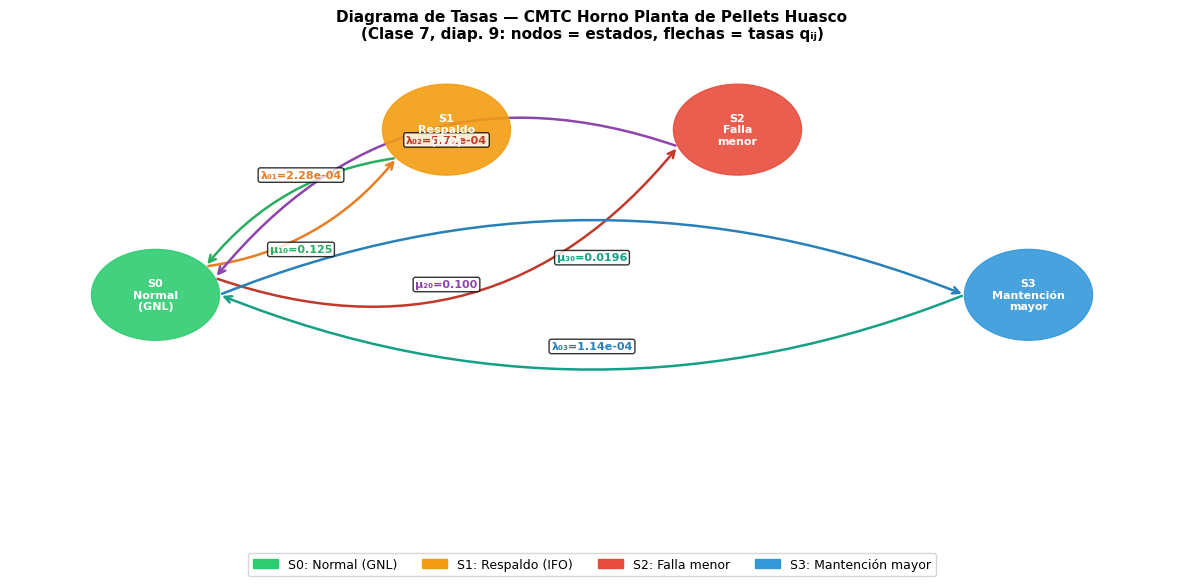

Tasas de salida de cada estado (νᵢ = suma de tasas de salida):
  ν_0 (S0: Normal) = 0.000913 /h  →  tiempo promedio en estado = 1095.0 h
  ν_1 (S1: IFO) = 0.125000 /h  →  tiempo promedio en estado = 8.0 h
  ν_2 (S2: Falla) = 0.100000 /h  →  tiempo promedio en estado = 10.0 h
  ν_3 (S3: Mantención) = 0.019608 /h  →  tiempo promedio en estado = 51.0 h


In [ ]:
# ============================================================
# DIAGRAMA DE TASAS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-1.2, 1.2)
ax.axis('off')

# Posiciones de los nodos
pos = {0: (0, 0), 1: (1, 0.8), 2: (2, 0.8), 3: (3, 0)}
colores_nodo = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
etiquetas_nodo = ['S0\nNormal\n(GNL)', 'S1\nRespaldo\n(IFO)', 'S2\nFalla\nmenor', 'S3\nMantención\nmayor']

# Dibujar nodos
radio = 0.22
for i, (x, y) in pos.items():
    circ = plt.Circle((x, y), radio, color=colores_nodo[i], zorder=3, alpha=0.9)
    ax.add_patch(circ)
    ax.text(x, y, etiquetas_nodo[i], ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=4,
            multialignment='center')

# Función auxiliar: dibuja flecha curva entre dos nodos
def flecha(ax, p1, p2, etiqueta, color, offset_x=0, offset_y=0.15, curva=0.25):
    x1, y1 = p1; x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    ax.annotate('', xy=(x2 - radio * dx / np.hypot(dx,dy),
                        y2 - radio * dy / np.hypot(dx,dy)),
                xytext=(x1 + radio * dx / np.hypot(dx,dy),
                        y1 + radio * dy / np.hypot(dx,dy)),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
                                connectionstyle=f'arc3,rad={curva}'),
                zorder=2)
    mx = (x1 + x2) / 2 + offset_x
    my = (y1 + y2) / 2 + offset_y
    ax.text(mx, my, etiqueta, ha='center', va='center', fontsize=8,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# --- Flechas de salida desde S0 ---
flecha(ax, pos[0], pos[1], f'λ₀₁={lambda_01:.2e}', '#e67e22', offset_y= 0.18, curva=0.2)
flecha(ax, pos[0], pos[2], f'λ₀₂={lambda_02:.2e}', '#c0392b', offset_y= 0.35, curva=0.35)
flecha(ax, pos[0], pos[3], f'λ₀₃={lambda_03:.2e}', '#2980b9', offset_y=-0.25, curva=-0.2)

# --- Flechas de retorno a S0 ---
flecha(ax, pos[1], pos[0], f'μ₁₀={mu_10:.3f}',  '#27ae60', offset_y=-0.18, curva=0.2)
flecha(ax, pos[2], pos[0], f'μ₂₀={mu_20:.3f}',  '#8e44ad', offset_y=-0.35, curva=0.35)
flecha(ax, pos[3], pos[0], f'μ₃₀={mu_30:.4f}', '#16a085', offset_y= 0.18, curva=-0.2)

ax.set_title('Diagrama de Tasas — CMTC Horno Planta de Pellets Huasco\n'
             '(Clase 7, diap. 9: nodos = estados, flechas = tasas qᵢⱼ)',
             fontsize=11, fontweight='bold')

# Leyenda
parches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(colores_nodo, ['S0: Normal (GNL)', 'S1: Respaldo (IFO)',
                                           'S2: Falla menor', 'S3: Mantención mayor'])]
ax.legend(handles=parches, loc='lower center', ncol=4, fontsize=9,
          bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

print('Tasas de salida de cada estado (νᵢ = suma de tasas de salida):')
for i, n in enumerate(nombres):
    nu = -Q[i, i]
    print(f'  ν_{i} ({n}) = {nu:.6f} /h  →  tiempo promedio en estado = {1/nu:.1f} h')

3. Calcular las probabilidades de largo plazo.


La distribución estacionaria $\pi = [\pi_0, \pi_1, \pi_2, \pi_3]$ satisface
:

$$\pi \mathbf{Q} = \mathbf{0} \qquad \text{y} \qquad \sum_j \pi_j = 1$$

**Procedimiento de solución**:
1. Transponer Q y reemplazar la última fila por la ecuación de normalización
2. Resolver el sistema lineal $A\,\pi^T = e_n$

In [ ]:
# ============================================================
# ESTADO ESTACIONARIO: πQ = 0  con  Σπ = 1
# Método: reemplazar última fila de Q^T por [1,1,1,1]
# (Clase 7, diapositiva 38 — código idéntico al visto en clase)
# ============================================================
n_estados = Q.shape[0]
A = Q.T.copy()
A[-1, :] = 1          # reemplazar última ecuación por Σπ = 1
b = np.zeros(n_estados)
b[-1] = 1

pi_est = np.linalg.solve(A, b)

print('=' * 55)
print('PROBABILIDADES ESTACIONARIAS π (largo plazo)')
print('=' * 55)
for i, (nombre, p) in enumerate(zip(nombres, pi_est)):
    barra = '█' * int(p * 50)
    print(f'  {nombre:20s}: {p:.6f}  ({p*100:.3f}%)  {barra}')
print(f'\n  Suma total = {pi_est.sum():.6f} ✓')

print('\nInterpretación')
print('  πⱼ = fracción del tiempo a largo plazo que el horno pasa en el estado j')
print()
print('Horas esperadas por año en cada estado:')
for nombre, p in zip(nombres, pi_est):
    print(f'  {nombre:20s}: {p * 8760:.1f} h/año')

PROBABILIDADES ESTACIONARIAS π (largo plazo)
  S0: Normal          : 0.986820  (98.682%)  █████████████████████████████████████████████████
  S1: IFO             : 0.001802  (0.180%)  
  S2: Falla           : 0.005633  (0.563%)  
  S3: Mantención      : 0.005745  (0.575%)  

  Suma total = 1.000000 ✓

Interpretación
  πⱼ = fracción del tiempo a largo plazo que el horno pasa en el estado j

Horas esperadas por año en cada estado:
  S0: Normal          : 8644.5 h/año
  S1: IFO             : 15.8 h/año
  S2: Falla           : 49.3 h/año
  S3: Mantención      : 50.3 h/año


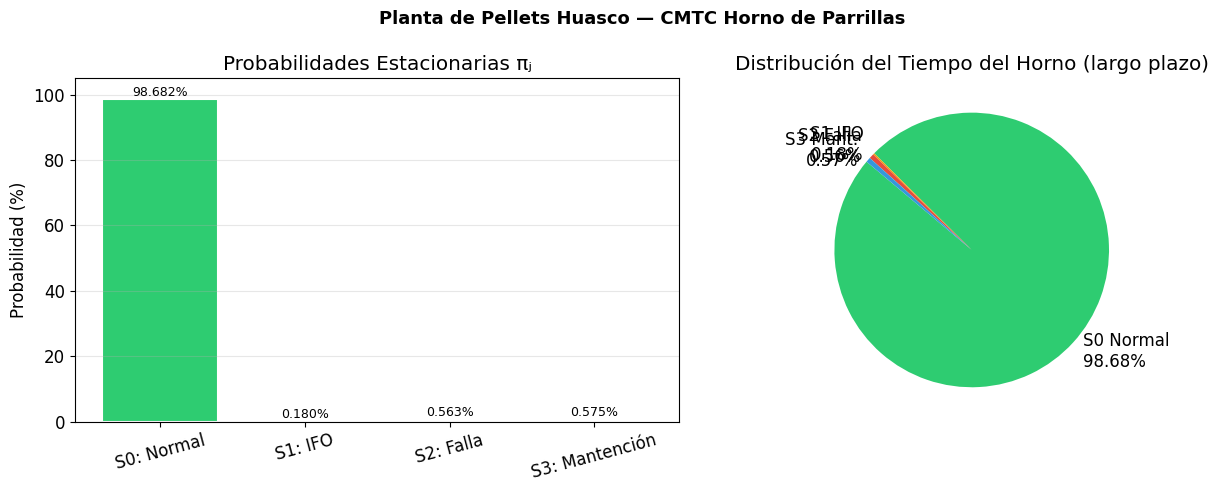

In [ ]:
# Visualización de probabilidades estacionarias
colores = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
etiquetas_pie = [f'{n}\n{p*100:.2f}%'
                 for n, p in zip(['S0 Normal', 'S1 IFO', 'S2 Falla', 'S3 Mant.'], pi_est)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras
bars = axes[0].bar(nombres, pi_est * 100, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_title('Probabilidades Estacionarias πⱼ')
axes[0].set_ylim(0, 105)
for bar, p in zip(bars, pi_est):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{p*100:.3f}%', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico de torta
axes[1].pie(pi_est, labels=etiquetas_pie, colors=colores,
            startangle=140, pctdistance=0.75)
axes[1].set_title('Distribución del Tiempo del Horno (largo plazo)')

plt.suptitle('Planta de Pellets Huasco — CMTC Horno de Parrillas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

4. Uitlizar las medidas de desempeño del núumero de clientes y tiempos. (Confiabilidad?,MTBF?, máquinas esperadas en servicio o equivalente)

**5.1 Disponibilidad y MTBF**

Usando el Teorema Ergódico: $E[f(X)] = \sum_j f(j)\,\pi_j$

- **Disponibilidad** $A$: fracción del tiempo en estados operativos (S0 + S1)
- **MTBF** (Mean Time Between Failures) = $1 / \nu_0$ donde $\nu_0$ es la tasa total de salida de S0  
  ($MTBF = 1/\mu$)
- **MTTR** (Mean Time To Repair): tiempo promedio de reparación ponderado por tipo de falla
- **Confiabilidad** $R(t) = e^{-\nu_0 t}$: probabilidad de no salir de S0 hasta tiempo $t$
- **Máquinas (hornos) esperados en servicio**: $E[X] = \sum_j j\,\pi_j$

In [ ]:
# ============================================================
# MEDIDAS DE DESEMPEÑO
# ============================================================

# Disponibilidad (A = suma de πⱼ en estados operativos)
A_total  = pi_est[0] + pi_est[1]   # S0 + S1: ambos producen pellets
A_plena  = pi_est[0]               # S0 solo: operación óptima

# Tasa total de salida de S0 = ν₀
nu_0 = lambda_01 + lambda_02 + lambda_03

# MTBF  (MTBF = 1/μ)
MTBF = 1 / nu_0

# MTTR ponderado por tipo de falla
w1 = lambda_01 / nu_0
w2 = lambda_02 / nu_0
w3 = lambda_03 / nu_0
MTTR = w1 * dur_falla_gnl + w2 * dur_falla_menor + w3 * dur_mant_mayor

# Máquinas (hornos) esperados en servicio — Teorema Ergódico (diap. 23)
# f(j) = 1 si estado operativo, 0 si no
f_operativo = np.array([1, 1, 0, 0])  # S0 y S1 producen; S2 y S3 no
E_operativo = np.dot(f_operativo, pi_est)

print('=' * 55)
print('MEDIDAS DE DESEMPEÑO DEL HORNO')
print('=' * 55)
print(f'  Disponibilidad total (S0+S1)  : {A_total*100:.3f}%')
print(f'  Disponibilidad plena (S0)     : {A_plena*100:.3f}%')
print(f'  No disponibilidad (S2+S3)     : {(1-A_total)*100:.3f}%')
print()
print(f'  Tasa total salida S0 (ν₀)     : {nu_0:.6f} /h')
print(f'  MTBF = 1/ν₀                   : {MTBF:.1f} horas = {MTBF/24:.1f} días')
print(f'  MTTR (ponderado)              : {MTTR:.2f} horas')
print()
print(f'  Hornos esperados en servicio  : {E_operativo:.4f} (de 1 horno total)')
print(f'  Horas improductivas/año       : {(1-A_total)*8760:.1f} h/año')

MEDIDAS DE DESEMPEÑO DEL HORNO
  Disponibilidad total (S0+S1)  : 98.862%
  Disponibilidad plena (S0)     : 98.682%
  No disponibilidad (S2+S3)     : 1.138%

  Tasa total salida S0 (ν₀)     : 0.000913 /h
  MTBF = 1/ν₀                   : 1095.0 horas = 45.6 días
  MTTR (ponderado)              : 14.62 horas

  Hornos esperados en servicio  : 0.9886 (de 1 horno total)
  Horas improductivas/año       : 99.7 h/año


**5.2. Confiabilidad**

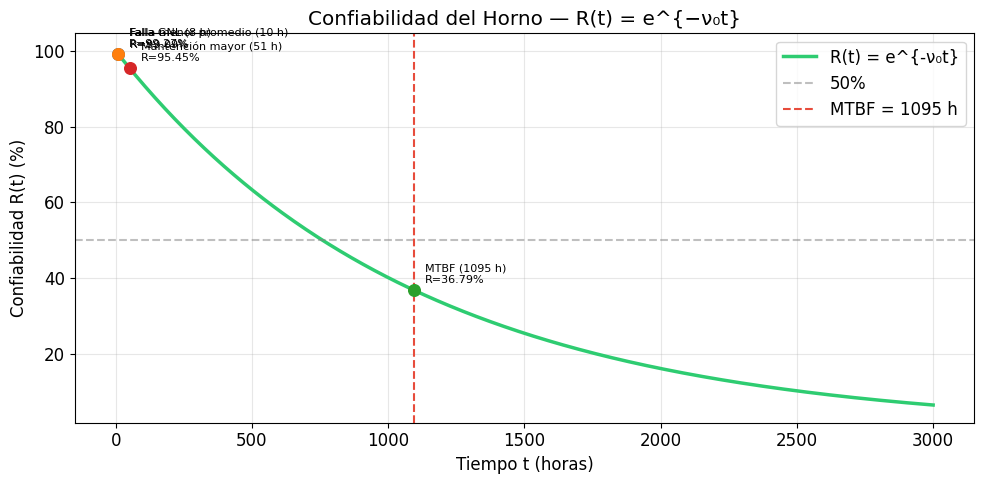

In [ ]:
# ============================================================
# CONFIABILIDAD R(t) = e^{-ν₀·t}
# Probabilidad de que el horno NO falle hasta el tiempo t
# ============================================================
t_horas = np.linspace(0, 3000, 500)
R_t = np.exp(-nu_0 * t_horas)

# Puntos de referencia del documento SEIA
t_ref = {
    'Falla GNL (8 h)':          8,
    'Falla menor promedio (10 h)': 10,
    f'MTBF ({MTBF:.0f} h)':     MTBF,
    'Mantención mayor (51 h)':  51
}

plt.figure(figsize=(10, 5))
plt.plot(t_horas, R_t * 100, color='#2ecc71', linewidth=2.5, label='R(t) = e^{-ν₀t}')
plt.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
plt.axvline(MTBF, color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'MTBF = {MTBF:.0f} h')

for label, tv in t_ref.items():
    rv = np.exp(-nu_0 * tv) * 100
    plt.scatter(tv, rv, zorder=5, s=70)
    plt.annotate(f'{label}\nR={rv:.2f}%', (tv, rv),
                 textcoords='offset points', xytext=(8, 5), fontsize=8)

plt.xlabel('Tiempo t (horas)')
plt.ylabel('Confiabilidad R(t) (%)')
plt.title('Confiabilidad del Horno — R(t) = e^{−ν₀t}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**5.3. Evolución Transitoria — Ecuaciones de Balance**

Las probabilidades en el tiempo satisfacen:
$$\frac{d\mathbf{p}(t)}{dt} = \mathbf{p}(t)\,\mathbf{Q}$$

Se resuelve numéricamente con el **método de Euler** (integración paso a paso), que es
el método más directo para resolver una EDO de primer orden:
$$\mathbf{p}(t + \Delta t) \approx \mathbf{p}(t) + \Delta t \cdot \mathbf{p}(t)\,\mathbf{Q}$$

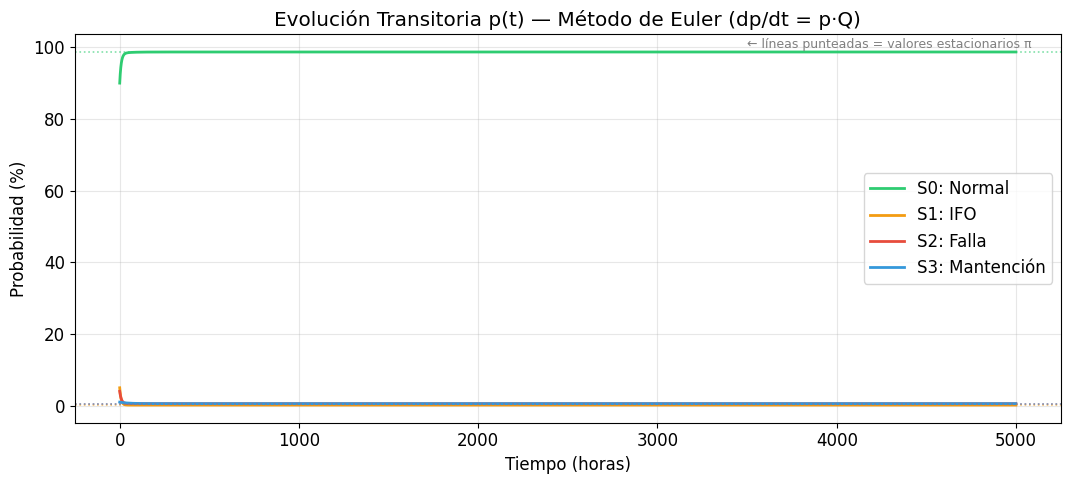

Estado estacionario alcanzado ≈ 73 horas (3.0 días)


In [ ]:
# ============================================================
# EVOLUCIÓN TRANSITORIA mediante método de Euler
# dp/dt = p(t) · Q  →  p(t+Δt) ≈ p(t) + Δt · p(t)·Q
# (Clase 7, diap. 8 — ecuación de balance global)
# ============================================================
dt     = 1.0          # paso de tiempo: 1 hora
T_max  = 5000         # horizonte: 5000 horas (~7 meses)
n_paso = int(T_max / dt)

tiempos     = np.arange(0, T_max, dt)
trayectoria = np.zeros((n_paso, 4))
trayectoria[0] = pi0.copy()

for k in range(1, n_paso):
    p = trayectoria[k-1]
    trayectoria[k] = p + dt * (p @ Q)   # Euler explícito
    # Proyectar en simplex (evitar valores negativos por acumulación numérica)
    trayectoria[k] = np.clip(trayectoria[k], 0, None)
    trayectoria[k] /= trayectoria[k].sum()

fig, ax = plt.subplots(figsize=(11, 5))
colores_tray = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
for i, (nombre, color) in enumerate(zip(nombres, colores_tray)):
    ax.plot(tiempos, trayectoria[:, i] * 100, label=nombre, color=color, linewidth=2)

# Líneas punteadas: valores estacionarios
for i, (p, color) in enumerate(zip(pi_est, colores_tray)):
    ax.axhline(p * 100, color=color, linestyle=':', alpha=0.6, linewidth=1.2)

ax.set_xlabel('Tiempo (horas)')
ax.set_ylabel('Probabilidad (%)')
ax.set_title('Evolución Transitoria p(t) — Método de Euler (dp/dt = p·Q)')
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)
ax.annotate('← líneas punteadas = valores estacionarios π',
            xy=(3500, pi_est[0]*100 + 1), fontsize=9, color='gray')
plt.tight_layout()
plt.show()

# Detectar cuándo se alcanza el estado estacionario
for k, p in enumerate(trayectoria):
    if np.max(np.abs(p - pi_est)) < 0.001:
        print(f'Estado estacionario alcanzado ≈ {tiempos[k]:.0f} horas ({tiempos[k]/24:.1f} días)')
        break

5. Hacer análisis de sensibilidad

Evaluamos cómo cambia la disponibilidad al variar los parámetros clave del modelo (Análisis de sensibilidad y decisión).

Variables a sensibilizar:

1. Frecuencia de fallas menores (rango SEIA: 4–6 por año)
2. Duración de la mantención mayor (SEIA: 51 h)

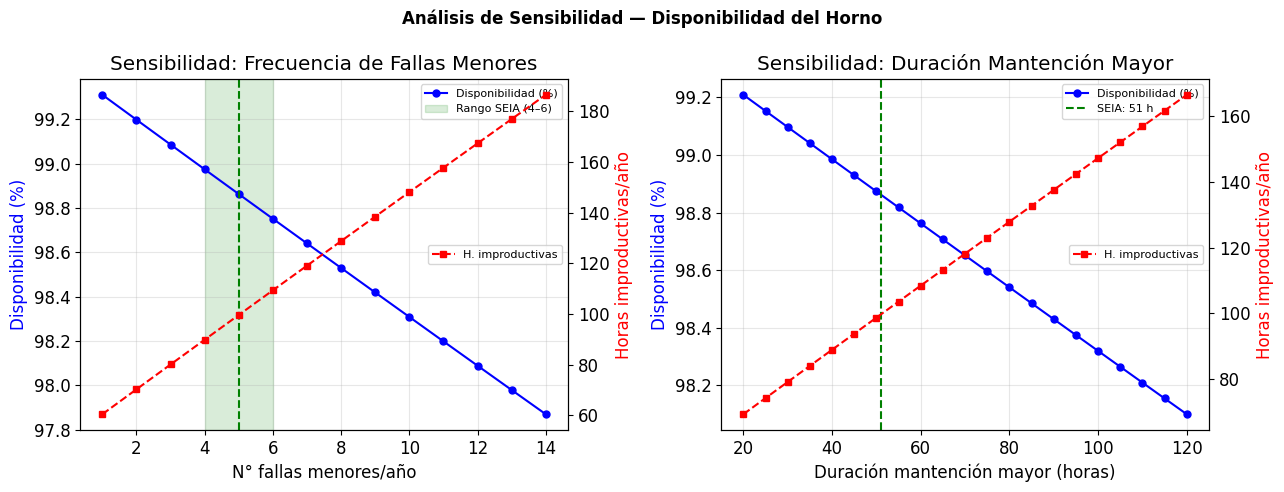

Escenario                               Disponib.(%)  H. improd./año
--------------------------------------------------------------------
Mejor caso: 4 fallas, 51 h mant.             98.9737            89.9
Caso base:  5 fallas, 51 h mant.             98.8622            99.7
Peor caso:  6 fallas, 51 h mant.             98.7510           109.4
Mant. optimizada: 5 fallas, 35 h             99.0407            84.0
Mant. extendida:  5 fallas, 70 h             98.6511           118.2


In [ ]:
# ============================================================
# ANÁLISIS DE SENSIBILIDAD
# ============================================================

def calcular_pi(n_fallas, dur_mant, n_gnl=2, dur_gnl=8, dur_falla=10):
    """Calcula π estacionario dado parámetros operacionales."""
    l01 = n_gnl    / 8760
    l02 = n_fallas / 8760
    l03 = 1        / 8760
    m10, m20, m30 = 1/dur_gnl, 1/dur_falla, 1/dur_mant
    Qx = np.array([
        [-(l01+l02+l03), l01, l02, l03],
        [m10, -m10, 0, 0],
        [m20, 0, -m20, 0],
        [m30, 0, 0, -m30]
    ])
    Ax = Qx.T.copy(); Ax[-1,:] = 1
    bx = np.zeros(4); bx[-1] = 1
    return np.linalg.solve(Ax, bx)

# Sensibilidad 1: variación de fallas menores (1 a 14/año)
rango_fallas  = np.arange(1, 15)
disp_fallas   = [(calcular_pi(n, dur_mant_mayor)[0] + calcular_pi(n, dur_mant_mayor)[1]) * 100
                 for n in rango_fallas]
h_imp_fallas  = [(100 - d) / 100 * 8760 for d in disp_fallas]

# Sensibilidad 2: variación duración mantención (20 a 120 h)
rango_mant    = np.arange(20, 125, 5)
disp_mant     = [(calcular_pi(n_fallas_menores, dm)[0] + calcular_pi(n_fallas_menores, dm)[1]) * 100
                 for dm in rango_mant]
h_imp_mant    = [(100 - d) / 100 * 8760 for d in disp_mant]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1
ax1 = axes[0]; ax1b = ax1.twinx()
ax1.plot(rango_fallas, disp_fallas, 'b-o', markersize=5, label='Disponibilidad (%)')
ax1b.plot(rango_fallas, h_imp_fallas, 'r--s', markersize=5, label='H. improductivas')
ax1.axvspan(4, 6, alpha=0.15, color='green', label='Rango SEIA (4–6)')
ax1.axvline(n_fallas_menores, color='green', linestyle='--', linewidth=1.5)
ax1.set_xlabel('N° fallas menores/año')
ax1.set_ylabel('Disponibilidad (%)', color='blue')
ax1b.set_ylabel('Horas improductivas/año', color='red')
ax1.set_title('Sensibilidad: Frecuencia de Fallas Menores')
ax1.legend(loc='upper right', fontsize=8)
ax1b.legend(loc='center right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2
ax2 = axes[1]; ax2b = ax2.twinx()
ax2.plot(rango_mant, disp_mant, 'b-o', markersize=5, label='Disponibilidad (%)')
ax2b.plot(rango_mant, h_imp_mant, 'r--s', markersize=5, label='H. improductivas')
ax2.axvline(dur_mant_mayor, color='green', linestyle='--', linewidth=1.5,
            label=f'SEIA: {dur_mant_mayor} h')
ax2.set_xlabel('Duración mantención mayor (horas)')
ax2.set_ylabel('Disponibilidad (%)', color='blue')
ax2b.set_ylabel('Horas improductivas/año', color='red')
ax2.set_title('Sensibilidad: Duración Mantención Mayor')
ax2.legend(loc='upper right', fontsize=8)
ax2b.legend(loc='center right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('Análisis de Sensibilidad — Disponibilidad del Horno',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de escenarios
print(f'{"Escenario":<38} {"Disponib.(%)": >13} {"H. improd./año":>15}')
print('-' * 68)
escenarios = [
    ('Mejor caso: 4 fallas, 51 h mant.',  4, 51),
    ('Caso base:  5 fallas, 51 h mant.',  5, 51),
    ('Peor caso:  6 fallas, 51 h mant.',  6, 51),
    ('Mant. optimizada: 5 fallas, 35 h',  5, 35),
    ('Mant. extendida:  5 fallas, 70 h',  5, 70),
]
for nombre, nf, dm in escenarios:
    pi_s = calcular_pi(nf, dm)
    d = (pi_s[0] + pi_s[1]) * 100
    h = (1 - d/100) * 8760
    print(f'{nombre:<38} {d:>13.4f} {h:>15.1f}')

6. Estudiar los costos y buscar óptimo



Usando la fórmula de costo promedio de largo plazo:

$$C^* = \sum_{j \in S} c(j)\,\pi_j$$

donde $c(j)$ es el costo por hora en el estado $j$.

| Estado | Costo por hora $c(j)$ |
|--------|----------------------|
| S0: Normal | USD 0 (operación normal) |
| S1: IFO | USD 2.000/h (costo adicional combustible más caro) |
| S2: Falla menor | USD 15.000/h (pérdida de producción + reparación) |
| S3: Mantención mayor | USD 3.922/h (costo fijo: USD 200.000 / 51 h) |

**Objetivo:** minimizar $C^*$ variando la **frecuencia de mantenciones mayores** (variable de diseño).

In [ ]:
# ============================================================
# COSTOS Y OPTIMIZACIÓN
# C* = Σ c(j) · πⱼ
# ============================================================

costo_parada_h    = 15_000    # USD/h en S2 (falla no planificada)
costo_ifo_h       = 2_000     # USD/h en S1 (combustible más costoso)
costo_mant_total  = 200_000   # USD por evento de mantención mayor

def costo_estrella(n_mant_anual, dur_mant=51, n_fallas=5):
    """
    C* = Σ c(j)·πⱼ  para el horno con n_mant_anual mantenciones/año.
    Con más mantenciones: se reduce la frecuencia de fallas menores (efecto preventivo).
    """
    n_fallas_adj = max(1.0, n_fallas - (n_mant_anual - 1) * 0.8)
    lam03_adj    = n_mant_anual / 8760
    l01 = n_falla_gnl  / 8760
    l02 = n_fallas_adj / 8760
    m10, m20, m30 = 1/dur_falla_gnl, 1/dur_falla_menor, 1/dur_mant

    Qc = np.array([
        [-(l01+l02+lam03_adj), l01, l02, lam03_adj],
        [m10, -m10, 0, 0],
        [m20, 0, -m20, 0],
        [m30, 0, 0, -m30]
    ])
    Ac = Qc.T.copy(); Ac[-1,:] = 1
    bc = np.zeros(4); bc[-1] = 1
    pi_c = np.linalg.solve(Ac, bc)

    # c(j) = costo por hora en cada estado
    c_hora_mant = costo_mant_total / dur_mant   # costo distribuido en horas de mantención
    c_j = np.array([0, costo_ifo_h, costo_parada_h, c_hora_mant])

    # C* = Σ c(j) · πⱼ
    C_estrella = np.dot(c_j, pi_c)

    return {
        'n_mant':         n_mant_anual,
        'disponib':       (pi_c[0] + pi_c[1]) * 100,
        'pi':             pi_c,
        'C_estrella_hora': C_estrella,
        'C_estrella_anio': C_estrella * 8760
    }

resultados = [costo_estrella(n) for n in range(1, 5)]

print('=' * 75)
print('ANÁLISIS DE COSTOS  C* = Σ c(j)·πⱼ')
print('=' * 75)
print(f'{"N° Mant/año":>12} {"Disponib.(%)": >14} {"C* (USD/hora)": >15} {"C* (USD/año)": >15}')
print('-' * 60)
for r in resultados:
    print(f'{r["n_mant"]:>12}  {r["disponib"]:>13.3f}  '
          f'{r["C_estrella_hora"]:>14,.2f}  {r["C_estrella_anio"]:>14,.0f}')

optimo = min(resultados, key=lambda x: x['C_estrella_anio'])
print(f'\n✅ ÓPTIMO: {optimo["n_mant"]} mantención(es) mayor(es) por año')
print(f'   C* mínimo = USD {optimo["C_estrella_hora"]:.2f}/h  =  USD {optimo["C_estrella_anio"]:,.0f}/año')
print(f'   Disponibilidad = {optimo["disponib"]:.3f}%')

ANÁLISIS DE COSTOS  C* = Σ c(j)·πⱼ
 N° Mant/año   Disponib.(%)   C* (USD/hora)    C* (USD/año)
------------------------------------------------------------
           1         98.862          110.62         969,057
           2         98.386          119.06       1,042,951
           3         97.914          127.41       1,116,135
           4         97.446          135.69       1,188,621

✅ ÓPTIMO: 1 mantención(es) mayor(es) por año
   C* mínimo = USD 110.62/h  =  USD 969,057/año
   Disponibilidad = 98.862%


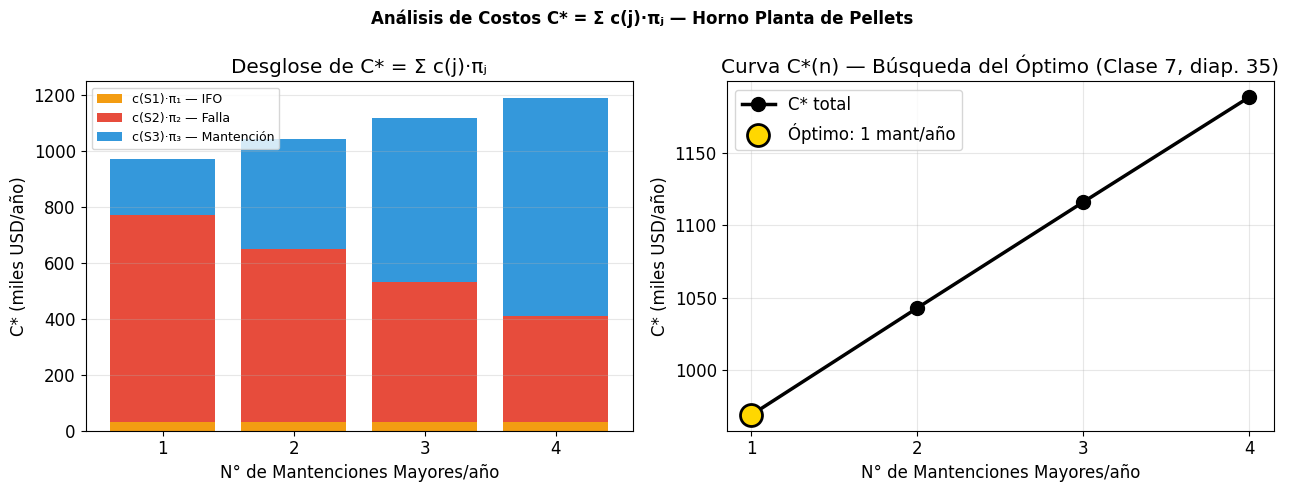

In [ ]:
# Visualización curva de C*
n_mants  = [r['n_mant'] for r in resultados]
c_anio   = [r['C_estrella_anio'] / 1000 for r in resultados]   # en miles USD

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Desglose por estado
c_s1 = [costo_ifo_h     * r['pi'][1] * 8760 / 1000 for r in resultados]
c_s2 = [costo_parada_h  * r['pi'][2] * 8760 / 1000 for r in resultados]
c_s3 = [(costo_mant_total/dur_mant_mayor) * r['pi'][3] * 8760 / 1000 for r in resultados]
x    = np.array(n_mants)

axes[0].bar(x, c_s1, label='c(S1)·π₁ — IFO',       color='#f39c12')
axes[0].bar(x, c_s2, bottom=c_s1, label='c(S2)·π₂ — Falla',    color='#e74c3c')
axes[0].bar(x, c_s3, bottom=[a+b for a,b in zip(c_s1,c_s2)],
            label='c(S3)·π₃ — Mantención', color='#3498db')
axes[0].set_xlabel('N° de Mantenciones Mayores/año')
axes[0].set_ylabel('C* (miles USD/año)')
axes[0].set_title('Desglose de C* = Σ c(j)·πⱼ')
axes[0].legend(fontsize=9)
axes[0].set_xticks(x)
axes[0].grid(True, alpha=0.3, axis='y')

# Curva de costo total
axes[1].plot(n_mants, c_anio, 'ko-', linewidth=2.5, markersize=10, label='C* total')
idx_opt = np.argmin(c_anio)
axes[1].scatter(n_mants[idx_opt], c_anio[idx_opt], color='gold', s=250,
                zorder=5, edgecolors='black', linewidth=2,
                label=f'Óptimo: {n_mants[idx_opt]} mant/año')
axes[1].set_xlabel('N° de Mantenciones Mayores/año')
axes[1].set_ylabel('C* (miles USD/año)')
axes[1].set_title('Curva C*(n) — Búsqueda del Óptimo (Clase 7, diap. 35)')
axes[1].legend()
axes[1].set_xticks(x)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Costos C* = Σ c(j)·πⱼ — Horno Planta de Pellets',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**7. Análisis de resultados:**

**Matriz Q**:

- Se observa que las transiciones a estados de falla (S1, S2, S3) son de muy baja frecuencia, mientras que las tasas de retorno a S0 (normal) son más elevadas una vez que la falla o mantención ocurre.

**Probabilidades Estacionarias (Largo Plazo):**

- A largo plazo, el sistema converge a una distribución de probabilidades que indica la mayor parte del tiempo en el estado de operación normal. Específicamente:

    - S0 (Normal): 98.682% del tiempo.

    - S1 (Respaldo IFO): 0.180% del tiempo.

    - S2 (Falla Menor): 0.563% del tiempo.

    - S3 (Mantención Mayor): ~0.575% del tiempo.

- Esto se traduce en que el horno operará en condiciones normales la mayor parte del tiempo, lo cual es muy favorable.

**Medidas de Desempeño:**

- **Disponibilidad Total (S0+S1):** 98.862%, indicando que el horno está disponible para producir casi todo el tiempo.

- **Tiempo Medio Entre Fallas (MTBF)Aproximadamente 1095 horas (45.6 días), lo que significa que, en promedio, transcurren 45.6 días antes de que el sistema salga de su estado de operación normal.

- **Tiempo Medio de Reparación (MTTR) Ponderado:** 14.62 horas. Este es el tiempo promedio para restaurar el sistema a un estado operativo después de una interrupción.

- **Horas Improductivas/año:** Alrededor de 99.7 horas al año o dias aproximadamente.

**Evolución transitoria:**

- El análisis mostró que el sistema alcanza su estado estacionario (es decir, las probabilidades se estabilizan) en aproximadamente 73 horas (3 días). Esto significa que el comportamiento a largo plazo de la operación del horno se establece relativamente rápido, independientemente de su estado inicial.

**Análisis de sensibilidad:**

- **Frecuencia de Fallas Menores:** Un aumento en las fallas menores disminuye linealmente la disponibilidad y aumenta las horas improductivas. Mantener la frecuencia entre 4 y 6 fallas al año (rango SEIA) es crucial.

- **Duración de la Mantención Mayor:*** Un incremento en la duración de la mantención mayor también reduce la disponibilidad y aumenta las horas improductivas, aunque con un impacto ligeramente menor que las fallas menores.

**Optimización de Costos:**

- El análisis de costos promedio a largo plazo reveló que la estrategia óptima es realizar 1 mantención mayor por año. A partir de esta frecuencia, aumentar el número de mantenciones anuales incrementa el costo total operativo. El costo mínimo anual es de USD 969,057 con una disponibilidad del 98.862%.